# MC_DELAY_PER_TRAIN Calibratie

Dit notebook onderzoekt welke waarde voor `MC_DELAY_PER_TRAIN` de beste balans geeft
tussen **solver effort** (`n_rescheduled`) en **performantie** (`TED_combined`).

**Wat meten we?**
- Een lage `MC_DELAY_PER_TRAIN` → threshold ligt laag → trigger vuurt snel → veel reschedules, lage delay
- Een hoge `MC_DELAY_PER_TRAIN` → threshold ligt hoog → trigger vuurt zelden → weinig reschedules, hogere delay
- We zoeken het knikpunt: waar stijgt de delay zonder dat de solver significant minder werkt?

**Aanpak:** meerdere seeds per waarde voor robuuste schatting.

In [4]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path.cwd().parent))

import config.settings as settings
from run_simulation import run_simulation
from utils.metrics import compute_metrics

## Configuratie

In [7]:
# --- Te testen waarden voor MC_DELAY_PER_TRAIN (seconden, gemiddelde per trein) ---
MC_VALUES = [ 5,20, 40, 60, 90, 120, 180, 240,300]

# --- Seeds per waarde: meer seeds = betrouwbaardere schatting, maar trager ---
SEEDS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# --- Vaste simulatieparameters (zelfde als je hoofdexperiment) ---
SIM_PARAMS = dict(
    n_freight            = 182,
    trigger_strategy     = "event_driven", #"event_driven",   # puur event-driven: MC_DELAY_PER_TRAIN heeft hier maximale impact
    event_driven_freq    = 900,
    controller_freq      = 450,
    threshold_confidence = 0.6,
    objective_strategy   = "static",
    weight_passenger     = 1,
    weight_freight       = 1,
    dynamic_threshold    = 180,
)

print(f"Grid: {len(MC_VALUES)} waarden × {len(SEEDS)} seeds = {len(MC_VALUES)*len(SEEDS)} runs")

Grid: 9 waarden × 10 seeds = 90 runs


## Sweep uitvoeren

We overschrijven `config.settings.MC_DELAY_PER_TRAIN` tijdelijk per run
en herladen de trigger-module zodat de nieuwe waarde opgepikt wordt.

In [8]:
import gc
import io
import contextlib

rows = []

for mc_val in MC_VALUES:
    print(f"\n{'='*60}")
    print(f"MC_DELAY_PER_TRAIN = {mc_val}s")
    print(f"{'='*60}")

    for seed in SEEDS:
        print(f"  seed={seed} ... ", end="", flush=True)

        # mc_delay_per_train direct meegeven — settings-module overschrijven
        # werkt NIET omdat triggers.py de waarde kopieert bij import-tijd.
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            state, df, meta, _ = run_simulation(
                **SIM_PARAMS,
                mc_delay_per_train = mc_val,
                seed               = seed,
                save               = False,
            )
        if meta["deadlock_detected"]:
            print(f"  seed={seed} mc={mc_val} → DEADLOCK (uitgesloten)")
            continue

        metrics = compute_metrics(df)
        ctrl    = meta.get("controller_summary", {})

        rows.append({
            "mc_delay_per_train" : mc_val,
            "seed"               : seed,
            "TED_combined"       : metrics.get("TED_combined"),
            "TED_passenger"      : metrics.get("TED_passenger"),
            "TED_freight"        : metrics.get("TED_freight"),
            "n_rescheduled"      : ctrl.get("n_rescheduled", 0),
            "n_skipped"          : ctrl.get("n_skipped", 0),
            "n_fcfs_fallback"    : ctrl.get("n_fcfs_fallback", 0),
            "total_solver_time"  : ctrl.get("total_solver_runtime_s", 0.0),
        })

        del state, df
        gc.collect()

        print(f"TED={metrics.get('TED_combined', float('nan')):.1f}s  "
              f"n_rescheduled={ctrl.get('n_rescheduled', 0)}")

raw = pd.DataFrame(rows)
print(f"\nKlaar — {len(raw)} runs")
raw


MC_DELAY_PER_TRAIN = 5s
  seed=0 ... TED=72787.0s  n_rescheduled=84
  seed=10 ... TED=72792.9s  n_rescheduled=88
  seed=20 ... TED=75039.5s  n_rescheduled=86
  seed=30 ... TED=78493.0s  n_rescheduled=89
  seed=40 ... TED=76951.9s  n_rescheduled=91
  seed=50 ... TED=75357.4s  n_rescheduled=89
  seed=60 ... TED=88122.0s  n_rescheduled=89
  seed=70 ... TED=75791.9s  n_rescheduled=89
  seed=80 ... TED=75935.5s  n_rescheduled=86
  seed=90 ... TED=67040.4s  n_rescheduled=85

MC_DELAY_PER_TRAIN = 20s
  seed=0 ... TED=72988.2s  n_rescheduled=85
  seed=10 ... TED=72680.9s  n_rescheduled=83
  seed=20 ... TED=75039.5s  n_rescheduled=86
  seed=30 ... TED=73535.0s  n_rescheduled=80
  seed=40 ... TED=78388.0s  n_rescheduled=91
  seed=50 ... TED=71536.2s  n_rescheduled=83
  seed=60 ... TED=81639.1s  n_rescheduled=85
  seed=70 ... TED=73445.9s  n_rescheduled=83
  seed=80 ... TED=74792.0s  n_rescheduled=79
  seed=90 ... TED=68014.8s  n_rescheduled=80

MC_DELAY_PER_TRAIN = 40s
  seed=0 ... TED=71798.4s

,mc_delay_per_train,seed,TED_combined,TED_passenger,TED_freight,n_rescheduled,n_skipped,n_fcfs_fallback,total_solver_time
0,5,0,72787.0,60457.2,12329.8,84,10722,0,0.730138
1,5,10,72792.9,59051.6,13741.3,88,10718,0,0.661548
2,5,20,75039.5,63684.7,11354.8,86,10720,0,0.689815
3,5,30,78493.0,63726.4,14766.6,89,10717,0,0.705594
4,5,40,76951.9,64928.8,12023.1,91,10715,0,0.680498
...,...,...,...,...,...,...,...,...,...
83,300,50,72936.7,60691.9,12244.8,48,10758,0,0.477447
84,300,60,88117.5,66747.9,21369.6,45,10761,0,0.431017
85,300,70,82300.2,68783.7,13516.5,43,10763,0,0.483217
86,300,80,75610.9,65852.4,9758.5,37,10769,0,0.355979


## Aggregatie per MC-waarde

In [9]:
agg = (
    raw
    .groupby("mc_delay_per_train")[["TED_combined", "TED_passenger", "TED_freight",
                                     "n_rescheduled", "total_solver_time"]]
    .agg(["mean", "std"])
    .round(2)
)
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.reset_index()
agg

,mc_delay_per_train,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_passenger_std,TED_freight_mean,TED_freight_std,n_rescheduled_mean,n_rescheduled_std,total_solver_time_mean,total_solver_time_std
0,5,75831.15,5333.80,62308.71,3058.08,13522.44,2979.58,87.60,2.22,0.69,0.04
1,20,74205.96,3712.95,61023.58,2295.79,13182.38,2786.78,83.50,3.54,0.67,0.02
2,40,73747.51,3707.15,61091.78,2977.75,12655.73,2317.56,80.20,1.93,0.67,0.03
3,60,74524.23,2338.29,61480.23,1691.47,13044.00,1587.34,77.78,2.33,0.68,0.03
4,90,75952.78,2464.94,62658.18,1989.26,13294.60,2050.95,76.10,2.13,0.67,0.02
5,120,76508.11,4767.82,63197.54,2654.65,13310.57,3729.83,72.50,2.92,0.69,0.05
6,180,76688.81,6897.40,63519.29,2642.21,13169.52,4530.31,66.00,3.46,0.64,0.06
7,240,76824.91,8182.51,64228.41,4400.35,12596.50,4003.38,50.44,17.60,0.47,0.18
8,300,78345.34,5770.42,65695.05,3383.84,12650.29,3548.93,41.40,3.69,0.42,0.04


## Plot: TED_combined en n_rescheduled vs MC_DELAY_PER_TRAIN

Twee assen: links de delay (lager = beter), rechts het aantal reschedules (lager = goedkoper).  
Het optimum ligt waar de delay laag blijft maar de reschedules significant dalen.

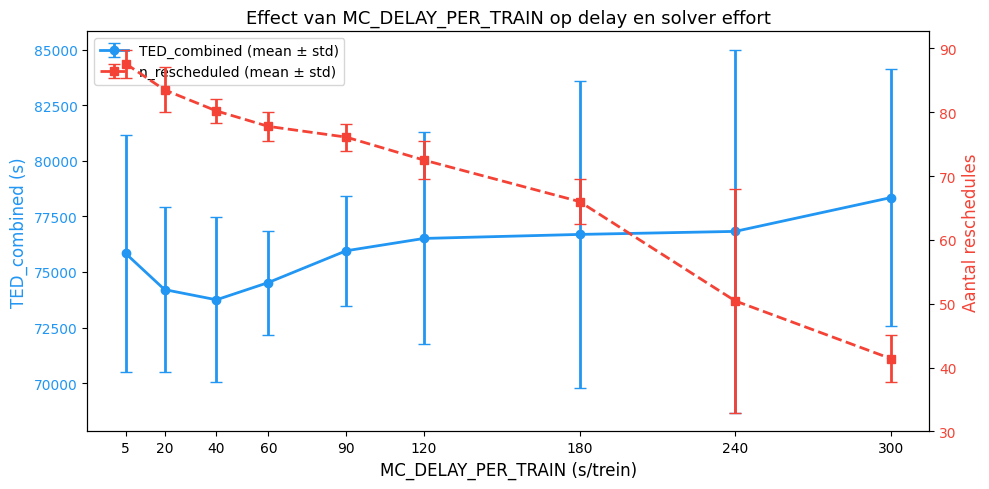

Figuur opgeslagen als mc_threshold_sweep.png


In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_ted   = "#2196F3"
color_reschedule = "#F44336"

x = agg["mc_delay_per_train"]

# --- TED_combined (links) ---
ax1.errorbar(
    x, agg["TED_combined_mean"], yerr=agg["TED_combined_std"],
    color=color_ted, marker="o", linewidth=2, capsize=4, label="TED_combined (mean ± std)"
)
ax1.set_xlabel("MC_DELAY_PER_TRAIN (s/trein)", fontsize=12)
ax1.set_ylabel("TED_combined (s)", color=color_ted, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_ted)
ax1.set_xticks(x)

# --- n_rescheduled (rechts) ---
ax2 = ax1.twinx()
ax2.errorbar(
    x, agg["n_rescheduled_mean"], yerr=agg["n_rescheduled_std"],
    color=color_reschedule, marker="s", linewidth=2, linestyle="--",
    capsize=4, label="n_rescheduled (mean ± std)"
)
ax2.set_ylabel("Aantal reschedules", color=color_reschedule, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_reschedule)

# Gecombineerde legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Effect van MC_DELAY_PER_TRAIN op delay en solver effort", fontsize=13)
plt.tight_layout()
plt.savefig("mc_threshold_sweep.png", dpi=150)
plt.show()
print("Figuur opgeslagen als mc_threshold_sweep.png")

## Plot: Pareto-front  (TED_combined vs n_rescheduled)

Elke punt is één MC-waarde (gemiddeld over seeds).  
Linksonder = ideaal. Punten op de Pareto-rand zijn de beste trade-offs.

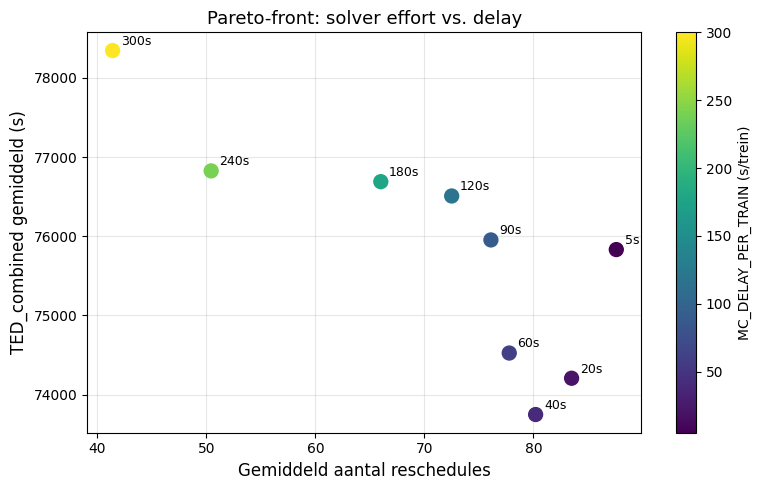

Figuur opgeslagen als mc_threshold_pareto.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    agg["n_rescheduled_mean"],
    agg["TED_combined_mean"],
    c=agg["mc_delay_per_train"],
    cmap="viridis",
    s=100,
    zorder=3,
)
plt.colorbar(scatter, ax=ax, label="MC_DELAY_PER_TRAIN (s/trein)")

# Label elk punt
for _, row in agg.iterrows():
    ax.annotate(
        f"{int(row['mc_delay_per_train'])}s",
        xy=(row["n_rescheduled_mean"], row["TED_combined_mean"]),
        xytext=(6, 4), textcoords="offset points", fontsize=9,
    )

ax.set_xlabel("Gemiddeld aantal reschedules", fontsize=12)
ax.set_ylabel("TED_combined gemiddeld (s)", fontsize=12)
ax.set_title("Pareto-front: solver effort vs. delay", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mc_threshold_pareto.png", dpi=150)
plt.show()
print("Figuur opgeslagen als mc_threshold_pareto.png")

## Numerieke samenvatting

Relatieve verandering t.o.v. de laagste MC-waarde (meest agressieve trigger).

In [12]:
baseline_ted  = agg["TED_combined_mean"].iloc[0]
baseline_resc = agg["n_rescheduled_mean"].iloc[0]

summary = agg[["mc_delay_per_train", "TED_combined_mean", "TED_combined_std",
               "n_rescheduled_mean", "n_rescheduled_std", "total_solver_time_mean"]].copy()

summary["TED_rel_%"]       = ((summary["TED_combined_mean"]  - baseline_ted)  / baseline_ted  * 100).round(1)
summary["reschedule_rel_%"] = ((summary["n_rescheduled_mean"] - baseline_resc) / baseline_resc * 100).round(1)

summary.columns = [
    "MC_DELAY_PER_TRAIN", "TED_mean", "TED_std",
    "n_rescheduled_mean", "n_rescheduled_std", "solver_time_mean",
    "ΔTED%", "Δreschedule%"
]
summary

,MC_DELAY_PER_TRAIN,TED_mean,TED_std,n_rescheduled_mean,n_rescheduled_std,solver_time_mean,ΔTED%,Δreschedule%
0,5,75831.15,5333.80,87.60,2.22,0.69,0.0,0.0
1,20,74205.96,3712.95,83.50,3.54,0.67,-2.1,-4.7
2,40,73747.51,3707.15,80.20,1.93,0.67,-2.7,-8.4
3,60,74524.23,2338.29,77.78,2.33,0.68,-1.7,-11.2
4,90,75952.78,2464.94,76.10,2.13,0.67,0.2,-13.1
5,120,76508.11,4767.82,72.50,2.92,0.69,0.9,-17.2
6,180,76688.81,6897.40,66.00,3.46,0.64,1.1,-24.7
7,240,76824.91,8182.51,50.44,17.60,0.47,1.3,-42.4
8,300,78345.34,5770.42,41.40,3.69,0.42,3.3,-52.7


## Conclusie

Kijk naar de rij waar:
- `Δreschedule%` significant daalt (solver bespaart moeite)
- `ΔTED%` nog acceptabel is (delay stijgt weinig)

De waarde net **vóór** de grote TED-sprong is de aanbevolen `MC_DELAY_PER_TRAIN`.

Stel de waarde in `config/settings.py` in:
```python
MC_DELAY_PER_TRAIN = <gekozen waarde>
```

In [13]:
# Optioneel: sla ruwe data op voor latere analyse
raw.to_csv("mc_threshold_raw.csv", index=False)
agg.to_csv("mc_threshold_agg.csv", index=False)
print("Data opgeslagen: mc_threshold_raw.csv, mc_threshold_agg.csv")

Data opgeslagen: mc_threshold_raw.csv, mc_threshold_agg.csv
